In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load prepared data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

feature_cols = joblib.load('../models/feature_cols.pkl')

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train mean: {y_train.mean():.1f}")
print(f"y_test  mean: {y_test.mean():.1f}")

X_train : (20268, 26)
X_test  : (4400, 26)
y_train mean: 171.4
y_test  mean: 112.4


In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.2f}  (avg error in AQI units)")
    print(f"  MAE  : {mae:.2f}  (avg absolute error)")
    print(f"  R²   : {r2:.4f} (1.0 = perfect)")
    print(f"{'='*40}")
    
    return {'Model': name, 'RMSE': round(rmse,2), 
            'MAE': round(mae,2), 'R2': round(r2,4)}

In [3]:
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest... (takes 1-2 minutes)")

rf_model = RandomForestRegressor(
    n_estimators=200,      # 200 trees
    max_depth=20,          # not too deep to avoid overfitting
    min_samples_leaf=5,    # each leaf needs at least 5 samples
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_results = evaluate_model("Random Forest", y_test, rf_preds)
print("\nRandom Forest training complete ✓")

Training Random Forest... (takes 1-2 minutes)

  Random Forest
  RMSE : 17.80  (avg error in AQI units)
  MAE  : 10.26  (avg absolute error)
  R²   : 0.9426 (1.0 = perfect)

Random Forest training complete ✓


In [4]:
from xgboost import XGBRegressor

print("Training XGBoost... (takes 30-60 seconds)")

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_test)
xgb_results = evaluate_model("XGBoost", y_test, xgb_preds)
print("\nXGBoost training complete ✓")

Training XGBoost... (takes 30-60 seconds)

  XGBoost
  RMSE : 19.77  (avg error in AQI units)
  MAE  : 12.10  (avg absolute error)
  R²   : 0.9292 (1.0 = perfect)

XGBoost training complete ✓


In [5]:
results_df = pd.DataFrame([rf_results, xgb_results])
print("\nMODEL COMPARISON TABLE")
print(results_df.to_string(index=False))

best_model_name = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
best_rmse = results_df['RMSE'].min()
print(f"\n🏆 Best model: {best_model_name} with RMSE = {best_rmse}")


MODEL COMPARISON TABLE
        Model  RMSE   MAE     R2
Random Forest 17.80 10.26 0.9426
      XGBoost 19.77 12.10 0.9292

🏆 Best model: Random Forest with RMSE = 17.8


In [6]:
joblib.dump(rf_model,  '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')

print("Models saved:")
print("  ../models/random_forest.pkl ✓")
print("  ../models/xgboost.pkl ✓")

Models saved:
  ../models/random_forest.pkl ✓
  ../models/xgboost.pkl ✓


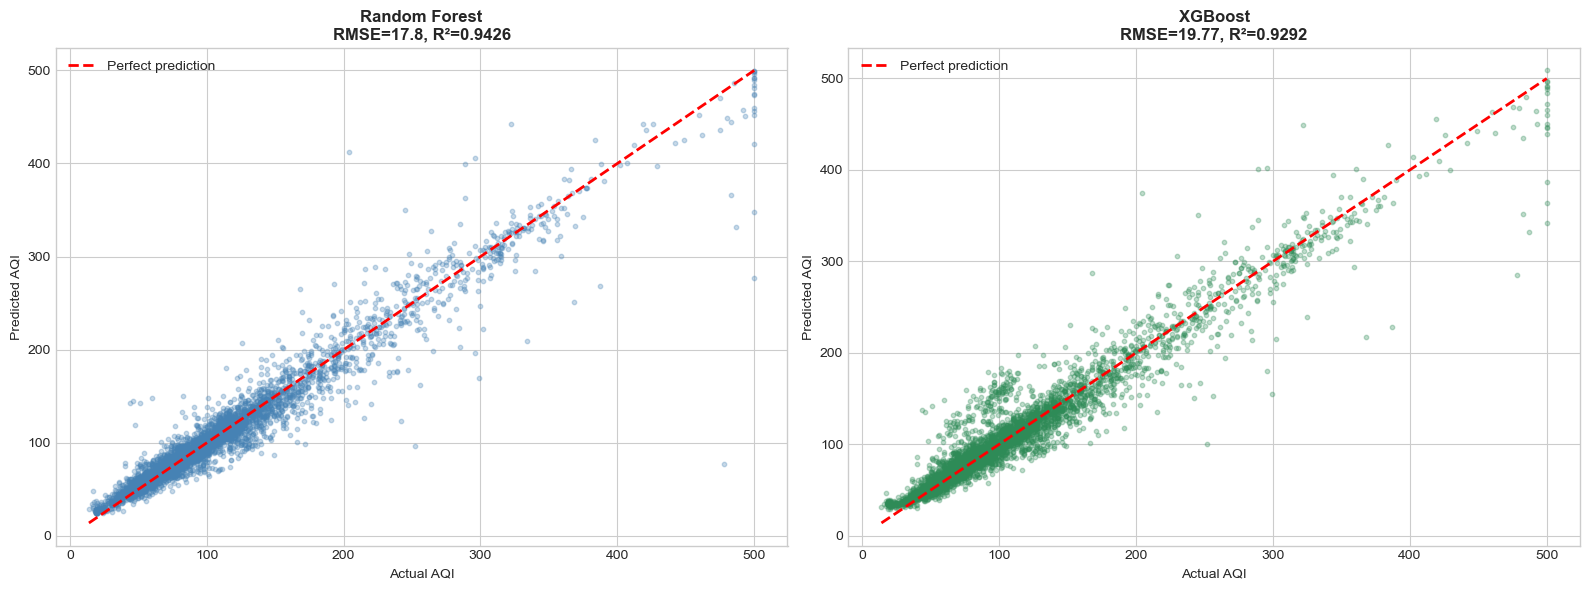

Plot saved ✓


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Random Forest ---
axes[0].scatter(y_test, rf_preds, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title(f'Random Forest\nRMSE={rf_results["RMSE"]}, R²={rf_results["R2"]}',
                  fontweight='bold')
axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Predicted AQI')
axes[0].legend()

# --- XGBoost ---
axes[1].scatter(y_test, xgb_preds, alpha=0.3, color='seagreen', s=10)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[1].set_title(f'XGBoost\nRMSE={xgb_results["RMSE"]}, R²={xgb_results["R2"]}',
                  fontweight='bold')
axes[1].set_xlabel('Actual AQI')
axes[1].set_ylabel('Predicted AQI')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visualizations/05_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

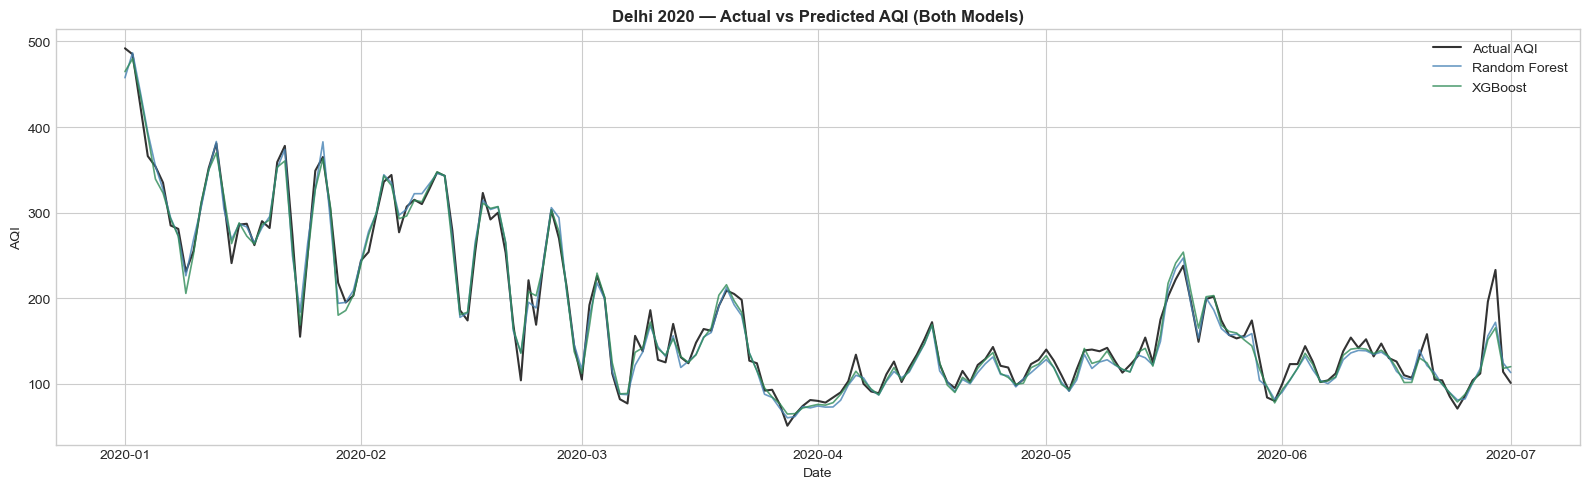

Plot saved ✓


In [8]:
# Show predictions over time for Delhi only
df_full = pd.read_csv('../data/featured_aqi.csv', parse_dates=['Date'])
test_data = df_full[df_full['Year'] == 2020].copy()
delhi_test = test_data[test_data['City'] == 'Delhi'].copy()

delhi_X = delhi_test[feature_cols]
delhi_rf_pred  = rf_model.predict(delhi_X)
delhi_xgb_pred = xgb_model.predict(delhi_X)

plt.figure(figsize=(16, 5))
plt.plot(delhi_test['Date'].values, delhi_test['AQI'].values,
         color='black', linewidth=1.5, label='Actual AQI', alpha=0.8)
plt.plot(delhi_test['Date'].values, delhi_rf_pred,
         color='steelblue', linewidth=1.2, label='Random Forest', alpha=0.8)
plt.plot(delhi_test['Date'].values, delhi_xgb_pred,
         color='seagreen', linewidth=1.2, label='XGBoost', alpha=0.8)
plt.title('Delhi 2020 — Actual vs Predicted AQI (Both Models)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/06_delhi_2020_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

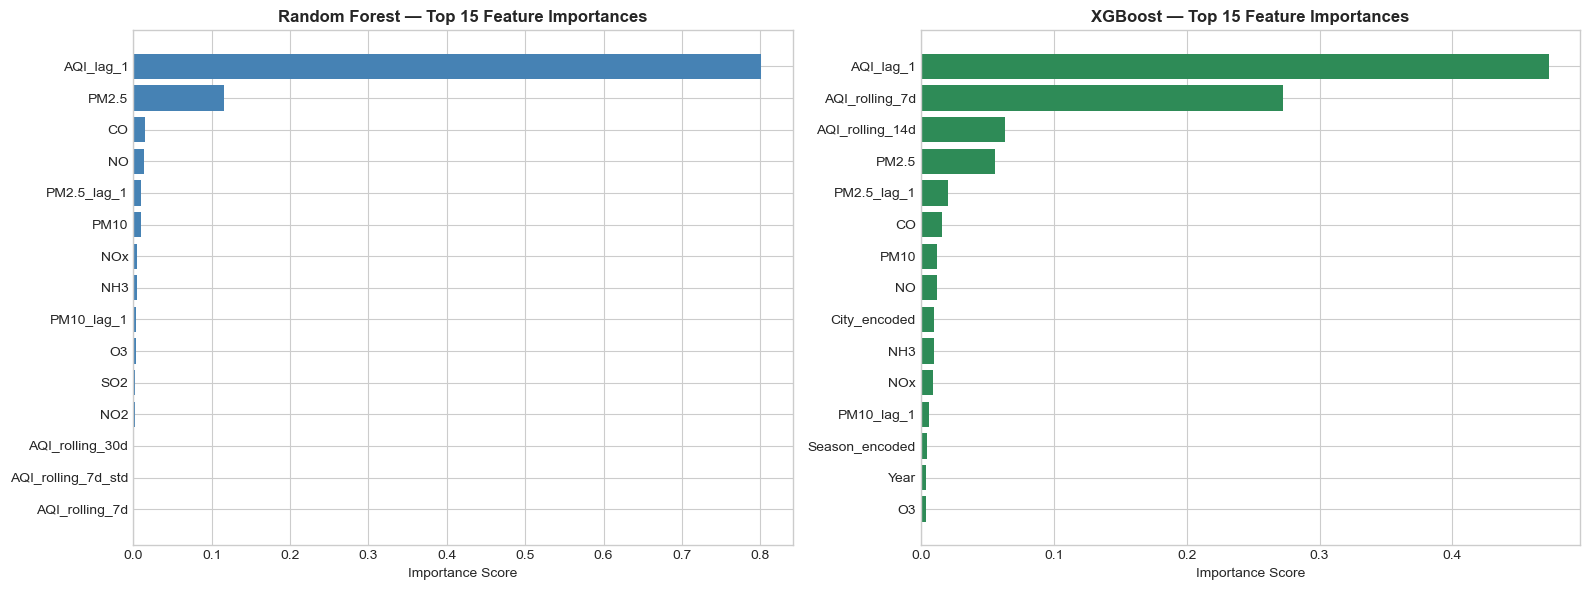

Plot saved ✓


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest importance
rf_importance = pd.Series(rf_model.feature_importances_, 
                           index=feature_cols).sort_values(ascending=True).tail(15)
axes[0].barh(rf_importance.index, rf_importance.values, color='steelblue')
axes[0].set_title('Random Forest — Top 15 Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost importance
xgb_importance = pd.Series(xgb_model.feature_importances_,
                             index=feature_cols).sort_values(ascending=True).tail(15)
axes[1].barh(xgb_importance.index, xgb_importance.values, color='seagreen')
axes[1].set_title('XGBoost — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../visualizations/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

In [10]:
print("\n" + "🎯 " * 15)
print("       PHASE 1 MODEL RESULTS SUMMARY")
print("🎯 " * 15)
print(f"""
  Dataset   : 26 Indian cities, 2015–2020
  Features  : 27 (lag, rolling, pollutants, time)
  Train set : 2015–2019
  Test set  : 2020

  ┌─────────────────┬────────┬────────┬────────┐
  │ Model           │  RMSE  │  MAE   │   R²   │
  ├─────────────────┼────────┼────────┼────────┤
  │ Random Forest   │  {rf_results['RMSE']:>6} │  {rf_results['MAE']:>6} │ {rf_results['R2']:>6} │
  │ XGBoost         │  {xgb_results['RMSE']:>6} │  {xgb_results['MAE']:>6} │ {xgb_results['R2']:>6} │
  └─────────────────┴────────┴────────┴────────┘

  🏆 Best Model : {best_model_name}
""")


🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 
       PHASE 1 MODEL RESULTS SUMMARY
🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 

  Dataset   : 26 Indian cities, 2015–2020
  Features  : 27 (lag, rolling, pollutants, time)
  Train set : 2015–2019
  Test set  : 2020

  ┌─────────────────┬────────┬────────┬────────┐
  │ Model           │  RMSE  │  MAE   │   R²   │
  ├─────────────────┼────────┼────────┼────────┤
  │ Random Forest   │    17.8 │   10.26 │ 0.9426 │
  │ XGBoost         │   19.77 │    12.1 │ 0.9292 │
  └─────────────────┴────────┴────────┴────────┘

  🏆 Best Model : Random Forest

